c:\Users\agz90fk\AppData\Local\anaconda3\envs\osmhistory\lib\site-packages\pyogrio\geopandas.py:275: UserWarning: More than one layer found in 'DE_VG250.gpkg': 'vg250_vwg' (default), 'vg250_sta', 'vg250_rbz', 'vg250_pk', 'vg250_li', 'vg250_lan', 'vg250_krs', 'vg250_gem', 'v_vg250_gem', 'v_vg250_vwg', 'v_vg250_krs', 'v_vg250_rbz', 'v_vg250_lan', 'v_vg250_sta', 'v_vg250_li', 'v_vg250_pk', 'v_vg250_f', 'v_vz250_gem', 'vgtb_vz_gem', 'vgtb_rgs_vg', 'vgtb_rgs_otl', 'vgtb_azb_vg', 'vg_werte', 'vg_ibz', 'vg_daten', 'v_at_vg', 'v_vgtb_att_vg', 'v_vgtb_azb_vg', 'v_vgtb_rgs_vg', 'v_vgtb_rgs_otl', 'v_vg_ibz', 'v_vg_sn_zahl', 'v_werte_agz', 'v_werte_rdg', 'v_werte_gm5', 'v_werte_gmk', 'v_werte_ade', 'v_werte_gf', 'v_werte_bsg', 'v_werte_nbd', 'v_werte_fks3', 'v_werte_spr'. Specify layer parameter to avoid this warning.
  result = read_func(


Bavarian districts in template: 96
Saved: C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Analysis_w_LoD2\Figures\template_bayern_residential_types.jpg


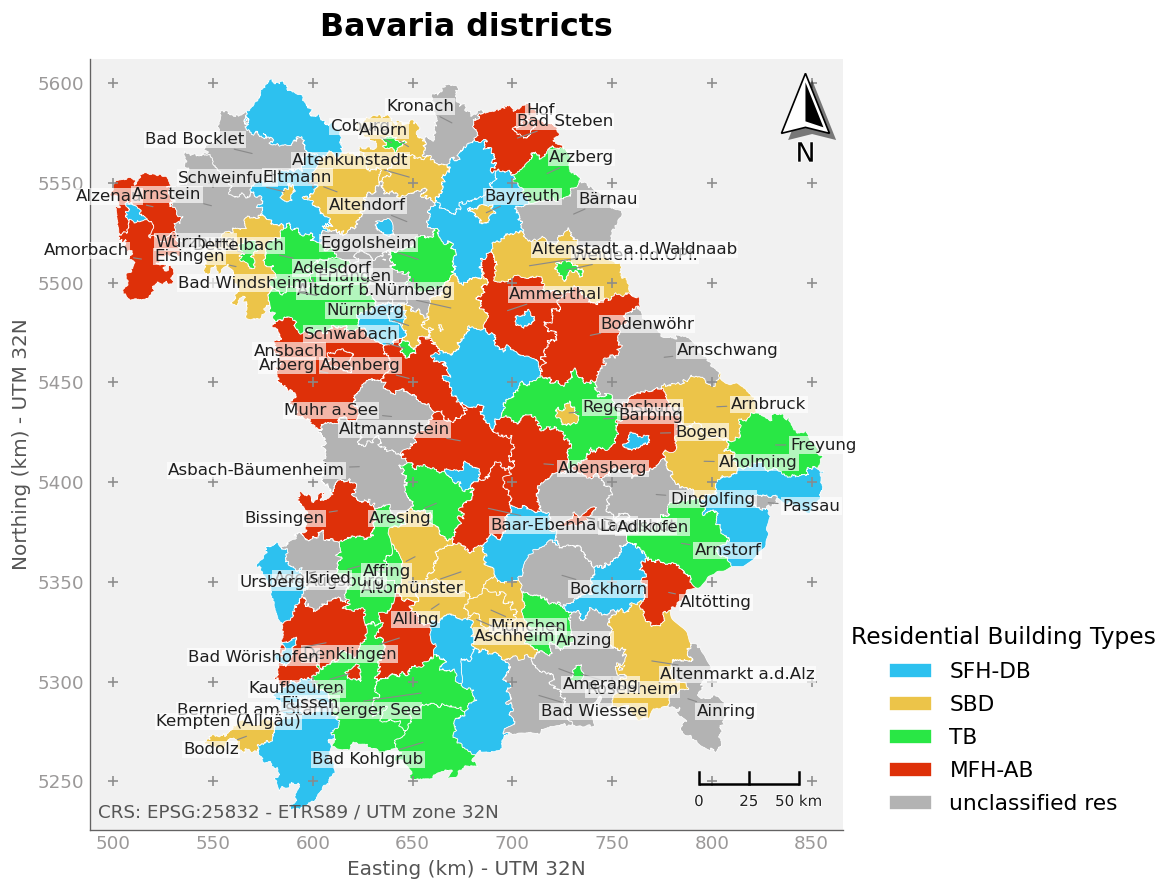

Saved: C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Analysis_w_LoD2\Figures\template_bayern_numeric.jpg


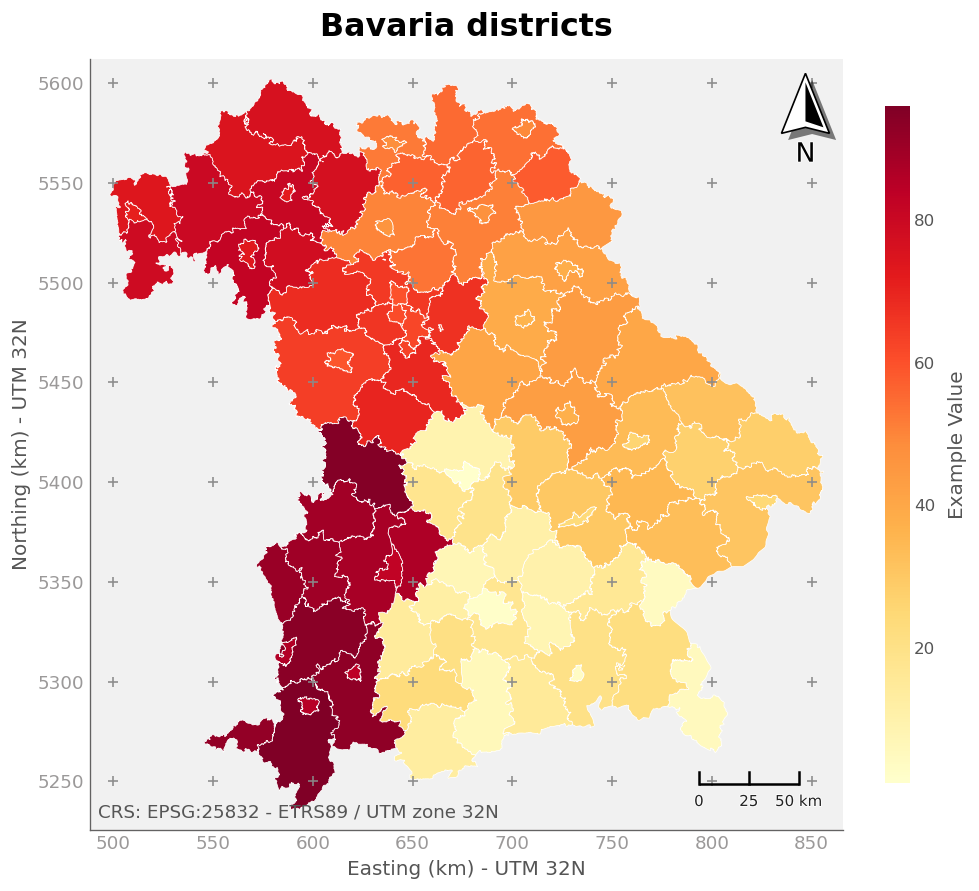

(<Figure size 1032x1128 with 2 Axes>,
 <Axes: title={'center': 'Bavaria districts'}, xlabel='Easting (km) - UTM 32N', ylabel='Northing (km) - UTM 32N'>)

In [ ]:
"""
Template for scientific choropleth maps on Bavarian district level.

Features:
- Base layer always: Bavaria districts
- subtle coordinate cross-grid in UTM
- legend in the lower-right margin
- scale bar in the lower-right corner
- north arrow in the upper-right corner
- optional labels positioned outside polygons with callout lines
- designed as a reusable layout for different maps
"""

import math
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import FuncFormatter

try:
    from matplotlib_map_utils import north_arrow, scale_bar
    HAS_MMU = True
except Exception:
    HAS_MMU = False

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 13,
    'axes.titlesize': 19,
    'axes.labelsize': 13,
    'legend.fontsize': 13,
    'legend.title_fontsize': 14,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
})

# ============================================================================
# CONFIGURATION
# ============================================================================

COL_ARS = 'ARS'
COL_NAME = 'GEN'
COL_GEOMETRY = 'geometry'
BAYERN_PREFIX = '09'
TARGET_CRS = 'EPSG:25832'
CRS_NOTE = 'CRS: EPSG:25832 - ETRS89 / UTM zone 32N'
GRID_STEP_M = 50000
MAP_PADDING_M = 10000
LABEL_OFFSET_M = 9000
COLOR_THEME = ['#f7da4b', '#f59c29', '#f26140', '#e63746', '#7b0f1c']
CUSTOM_CMAP = LinearSegmentedColormap.from_list('custom_orange_brown', COLOR_THEME)

PATH_LANDKREISE = r'C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Input\Verwaltungsgebiete\vg250-ew_12-31.utm32s.gpkg.ebenen\vg250-ew_ebenen_1231\DE_VG250.gpkg'
LAYER_LANDKREISE = 'v_vg25_krs'
OUTPUT_DIR = Path(r'C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Analysis_w_LoD2\Figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESIDENTIAL_TYPE_ORDER = ['SFH-DB', 'SBD', 'TB', 'MFH-AB', 'unclassified res']
COLOR_MAP_RESIDENTIAL_TYPES = {
    'SFH-DB': '#2dc1ef',
    'SBD': '#ecc449',
    'TB': '#29e745',
    'MFH-AB': '#de3009',
    'unclassified res': '#b3b3b3',
}

# ============================================================================
# HELPERS
# ============================================================================

def read_landkreise():
    try:
        gdf = gpd.read_file(PATH_LANDKREISE, layer=LAYER_LANDKREISE)
    except Exception:
        gdf = gpd.read_file(PATH_LANDKREISE)

    ars_col = COL_ARS if COL_ARS in gdf.columns else next((c for c in gdf.columns if 'ARS' in c or 'ars' in c), None)
    if ars_col is None:
        raise ValueError('No ARS column found.')

    gdf = gdf[gdf[ars_col].astype(str).str.startswith(BAYERN_PREFIX)].copy()
    if gdf.crs is None or str(gdf.crs) != TARGET_CRS:
        gdf = gdf.to_crs(TARGET_CRS)

    gdf['LK_KEY'] = gdf[ars_col].astype(str).str[:5]
    gdf['LK_NAME'] = gdf[COL_NAME].astype(str) if COL_NAME in gdf.columns else gdf['LK_KEY']

    gdf = gdf.dissolve(by='LK_KEY', as_index=False)
    if gdf.crs is None or str(gdf.crs) != TARGET_CRS:
        gdf = gdf.to_crs(TARGET_CRS)
    return gdf


def add_matplotlib_grid(ax, bounds, step=GRID_STEP_M):
    minx, miny, maxx, maxy = bounds
    x_start = math.ceil(minx / step) * step
    x_end = math.floor(maxx / step) * step
    y_start = math.ceil(miny / step) * step
    y_end = math.floor(maxy / step) * step

    x_major = [x_start + i * step for i in range(int((x_end - x_start) / step) + 1)] if x_start <= x_end else []
    y_major = [y_start + i * step for i in range(int((y_end - y_start) / step) + 1)] if y_start <= y_end else []

    ax.set_xticks(x_major)
    ax.set_yticks(y_major)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(round(x / 1000))}'))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{int(round(y / 1000))}'))

    if x_major and y_major:
        x_pts, y_pts = [], []
        for xv in x_major:
            for yv in y_major:
                x_pts.append(xv)
                y_pts.append(yv)
        ax.scatter(x_pts, y_pts, marker='+', s=30, linewidths=1.0, color='#8a8a8a', alpha=0.95, zorder=4, clip_on=True)

    ax.tick_params(axis='both', which='major', labelsize=11, length=0, colors='#9B9999')


def add_north_arrow(ax):
    if HAS_MMU:
        north_arrow(
            ax=ax,
            location='upper right',
            size='md',
            rotation={'degrees': 0},
            aob={
                'bbox_to_anchor': (0.985, 0.985),
                'bbox_transform': ax.transAxes,
                'pad': 0.06,
                'borderpad': 0.06,
                'facecolor': 'none',
                'edgecolor': 'none',
                'alpha': 1.0,
                'frameon': False,
            },
        )
        return

    ax.annotate(
        'N',
        xy=(0.965, 0.97),
        xytext=(0.965, 0.86),
        xycoords='axes fraction',
        textcoords='axes fraction',
        ha='center',
        va='center',
        fontsize=16,
        fontweight='bold',
        arrowprops=dict(arrowstyle='-|>', color='#222222', linewidth=1.4, shrinkA=0, shrinkB=0),
    )


def add_scale_bar(ax):
    if HAS_MMU:
        scale_bar(
            ax=ax,
            location='lower right',
            size='xs',
            style='ticks',
            bar={
                'projection': TARGET_CRS,
                'unit': 'km',
                'max': 50,
                'major_div': 2,
                'minor_div': 1,
                'minor_type': 'none',
                'reverse': False,
            },
            labels={
                'labels': ['0', '25', '50'],
                'style': 'major',
                'loc': 'below',
                'fontsize': 9,
            },
            units={'loc': 'text', 'label': 'km'},
            text={'fontfamily': 'sans-serif', 'fontsize': 9, 'textcolor': '#222222'},
            aob={
                'pad': 0.0,
                'borderpad': 1.0,
                'facecolor': 'none',
                'edgecolor': 'none',
                'alpha': 1.0,
                'frameon': False,
            },
        )
        return

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    span_x = x1 - x0
    span_y = y1 - y0

    total_km = 50
    segment_km = 25
    bar_len = total_km * 1000
    segment_len = segment_km * 1000

    x_start = x1 - span_x * 0.25
    y_start = y0 + span_y * 0.032

    ax.plot([x_start, x_start + bar_len], [y_start, y_start], color='#222222', linewidth=1.3, zorder=5)
    tick_h = span_y * 0.006
    for x in [x_start, x_start + segment_len, x_start + bar_len]:
        ax.plot([x, x], [y_start - tick_h, y_start + tick_h], color='#222222', linewidth=1.0, zorder=5)

    txt_y = y_start + span_y * 0.011
    ax.text(x_start, txt_y, '0', ha='center', va='bottom', fontsize=9, color='#222222')
    ax.text(x_start + segment_len, txt_y, '25', ha='center', va='bottom', fontsize=9, color='#222222')
    ax.text(x_start + bar_len, txt_y, '50 km', ha='center', va='bottom', fontsize=9, color='#222222')


def add_scientific_frame(ax, gdf_base):
    ax.set_facecolor('#f1f1f1')
    minx, miny, maxx, maxy = gdf_base.total_bounds
    bounds = (minx - MAP_PADDING_M, miny - MAP_PADDING_M, maxx + MAP_PADDING_M, maxy + MAP_PADDING_M)
    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])
    ax.margins(0)
    add_matplotlib_grid(ax, bounds)

    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])
    ax.set_autoscale_on(False)

    ax.set_xlabel('Easting (km) - UTM 32N', fontsize=12, color='#555555')
    ax.set_ylabel('Northing (km) - UTM 32N', fontsize=12, color='#555555')
    ax.text(0.01, 0.01, CRS_NOTE, transform=ax.transAxes, ha='left', va='bottom', fontsize=11, color='#555555')

    for side in ['top', 'right']:
        ax.spines[side].set_visible(False)
    for side in ['left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color('#636262')
        ax.spines[side].set_linewidth(0.8)


def add_legend_bottom_right(ax, handles, title):
    ax.legend(
        handles=handles,
        title=title,
        loc='lower left',
        bbox_to_anchor=(1.01, 0.02),
        borderaxespad=0.0,
        frameon=False,
        fontsize=13,
        title_fontsize=14,
        handlelength=2.0,
        labelspacing=0.6,
        borderpad=0.0,
    )


def add_numeric_colorbar_right_margin(fig, sm, label):
    cax = fig.add_axes([0.84, 0.20, 0.025, 0.60])
    cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(labelsize=10, length=0, colors='#555555', pad=2)
    cbar.set_label(label, fontsize=12, color='#555555', labelpad=8)


def add_outside_labels(ax, gdf, label_col, condition=None, offset_m=LABEL_OFFSET_M):
    """Place labels outside polygons with simple callout lines."""
    if label_col not in gdf.columns:
        return

    gdf_labels = gdf.copy()
    if condition is not None:
        gdf_labels = gdf_labels[condition(gdf_labels)]
    if gdf_labels.empty:
        return

    bounds = gdf.total_bounds
    center_x = (bounds[0] + bounds[2]) / 2
    center_y = (bounds[1] + bounds[3]) / 2

    points = gdf_labels.representative_point()
    for (_, row), p in zip(gdf_labels.iterrows(), points):
        dx = p.x - center_x
        dy = p.y - center_y
        norm = math.hypot(dx, dy)
        if norm == 0:
            dx, dy, norm = 1.0, 1.0, math.sqrt(2)
        ux, uy = dx / norm, dy / norm

        tx = p.x + ux * offset_m
        ty = p.y + uy * offset_m
        ha = 'left' if ux >= 0 else 'right'

        ax.annotate(
            str(row[label_col]),
            xy=(p.x, p.y),
            xytext=(tx, ty),
            textcoords='data',
            ha=ha,
            va='center',
            fontsize=10,
            color='#1f1f1f',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.65, pad=0.7),
            arrowprops=dict(arrowstyle='-', color='#8a8a8a', lw=0.7),
            zorder=6,
        )


def plot_choropleth_template(
    gdf_map,
    value_col,
    output_name,
    cmap='viridis',
    categorical=False,
    legend_title=None,
    label_col=None,
    label_condition=None,
):
    """Reusable choropleth template for Bavarian districts."""
    fig, ax = plt.subplots(figsize=(8.6, 9.4))
    fig.subplots_adjust(right=0.80, left=0.07, top=0.92, bottom=0.08)

    base = gdf_map.copy()

    if categorical:
        categories = [cat for cat in RESIDENTIAL_TYPE_ORDER if cat in pd.Series(base[value_col]).dropna().unique()]
        color_lookup = {cat: COLOR_MAP_RESIDENTIAL_TYPES.get(cat, '#b3b3b3') for cat in categories}
        facecolors = base[value_col].map(color_lookup).fillna('#b3b3b3')
        base.plot(ax=ax, color=facecolors, edgecolor='white', linewidth=0.45, zorder=2)
        handles = [mpatches.Patch(facecolor=color_lookup[c], edgecolor='white', label=str(c)) for c in categories]
        add_legend_bottom_right(ax, handles, legend_title or value_col)
    else:
        numeric_cmap = CUSTOM_CMAP if cmap == 'viridis' else cmap
        base.plot(ax=ax, column=value_col, cmap=numeric_cmap, edgecolor='white', linewidth=0.45, legend=False, zorder=2)
        sm = ScalarMappable(norm=Normalize(vmin=base[value_col].min(), vmax=base[value_col].max()), cmap=numeric_cmap)
        sm._A = []
        add_numeric_colorbar_right_margin(fig, sm, legend_title or value_col)

    if label_col is not None:
        add_outside_labels(ax, base, label_col, condition=label_condition)

    add_north_arrow(ax)
    add_scale_bar(ax)
    ax.set_title('Bavaria districts', pad=14, fontweight='bold')
    ax.set_aspect('equal')
    add_scientific_frame(ax, base)

    out_file = OUTPUT_DIR / f'{output_name}.jpg'
    plt.savefig(out_file, bbox_inches='tight', facecolor='white', format='jpg')
    print(f'Saved: {out_file}')

    plt.show()
    plt.close(fig)
    return fig, ax


def prepare_example_dataset(gdf_lk):
    sample = gdf_lk.copy()
    sample['residential_type_example'] = [RESIDENTIAL_TYPE_ORDER[i % len(RESIDENTIAL_TYPE_ORDER)] for i in range(len(sample))]
    sample['example_value'] = range(1, len(sample) + 1)
    return sample


# ============================================================================
# DEMO
# ============================================================================

gdf_bayern_lk = read_landkreise()
gdf_bayern_lk = prepare_example_dataset(gdf_bayern_lk)
print(f'Bavarian districts in template: {len(gdf_bayern_lk)}')

plot_choropleth_template(
    gdf_map=gdf_bayern_lk,
    value_col='residential_type_example',
    output_name='template_bayern_residential_types',
    categorical=True,
    legend_title='Residential Building Types',
    label_col='LK_NAME',
    label_condition=lambda df: df['residential_type_example'] != 'SFH-DB',
)

plot_choropleth_template(
    gdf_map=gdf_bayern_lk,
    value_col='example_value',
    output_name='template_bayern_numeric',
    cmap='YlOrRd',
    categorical=False,
    legend_title='Example Value',
)
